<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Columns: 785 entries, 6 to 0.590
dtypes: int64(785)
memory usage: 119.8 MB
None
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0569
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 8.7124e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 5.3343e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.7809e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 2.8165e-04
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 2.3573e-04
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 2.1748e-04
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━

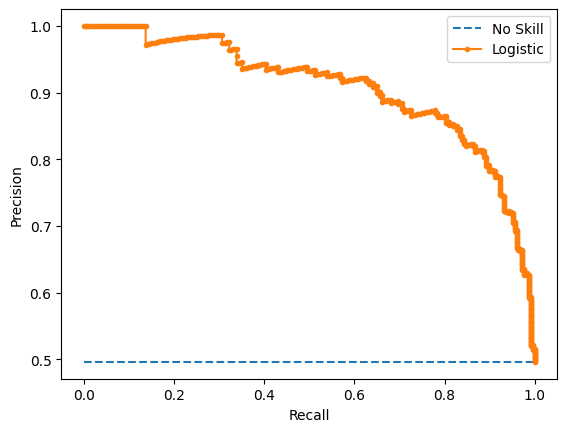

roc curve and auc:
No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.911


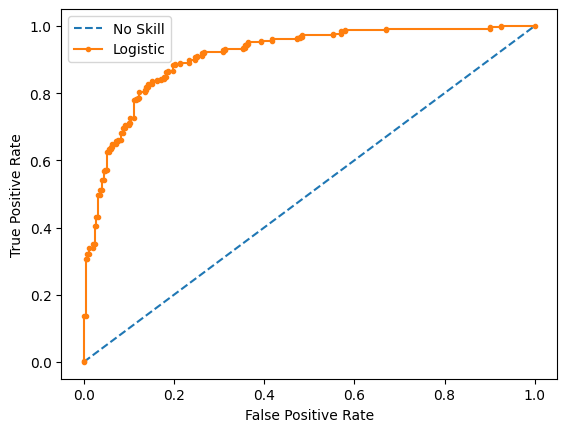

Skipping Bayesian Optimization due to missing data.
Runtime of the program is 92.57944893836975


In [10]:
import time
# starting time
start = time.time()

import matplotlib.pyplot as plt
# precision-recall curve and f1
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc

# roc curve and auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from matplotlib import pyplot


import pandas as pd
import numpy as np
import tensorflow as tf
dataset = pd.read_csv('/content/sample_data/mnist_train_small.csv')
dataset = dataset.dropna()
print(dataset.info())
dataset.head()
X = dataset.iloc[:, 0: -1].values
y = dataset.iloc[:, -1].values
from sklearn.preprocessing import LabelEncoder
LE1 = LabelEncoder()
X[:,4] = np.array(LE1.fit_transform(X[:,4]))
LE2 = LabelEncoder()
X[:,5] = np.array(LE2.fit_transform(X[:,5]))
LE3 = LabelEncoder()
X[:,32] = np.array(LE3.fit_transform(X[:,32]))
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct =ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.5,random_state=0)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)
#Analyze neural network
ann = tf.keras.models.Sequential()
#Adding First Hidden Layer
ann.add(tf.keras.layers.Dense(units=6,activation="relu"))
#Adding Second Hidden Layer
ann.add(tf.keras.layers.Dense(units=6,activation="relu"))
#Adding Output Layer
ann.add(tf.keras.layers.Dense(units=1,activation="sigmoid"))
#Compiling ANN
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])
#Fitting ANN
ann.fit(X_train,y_train,batch_size=32,epochs = 100)


# precision-recall curve and f1
print("precision-recall curve and f1:")
# generate 2 class dataset
X_prc, y_prc = make_classification(n_samples=1000, n_classes=2, random_state=1)
# Split the generated data for training and testing
X_train_prc, X_test_prc, y_train_prc, y_test_prc = train_test_split(X_prc, y_prc, test_size=0.5, random_state=1)

# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train_prc, y_train_prc) # Use the training part of the generated data
# predict probabilities
lr_probs = model.predict_proba(X_test_prc)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# predict class values
yhat = model.predict(X_test_prc)
lr_precision, lr_recall, _ = precision_recall_curve(y_test_prc, lr_probs)
lr_f1, lr_auc = f1_score(y_test_prc, yhat), auc(lr_recall, lr_precision)
# summarize scores
print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
# plot the precision-recall curves
no_skill = len(y_test_prc[y_test_prc==1]) / len(y_test_prc)
pyplot.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
pyplot.plot(lr_recall, lr_precision, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# roc curve and auc
print("roc curve and auc:")
# generate 2 class dataset
X_roc, y_roc = make_classification(n_samples=1000, n_classes=2, random_state=1)
# Split the generated data for training and testing
X_train_roc, X_test_roc, y_train_roc, y_test_roc = train_test_split(X_roc, y_roc, test_size=0.5, random_state=1)

# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(y_test_roc))]
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train_roc, y_train_roc)
# predict probabilities
lr_probs = model.predict_proba(X_test_roc)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# calculate scores
ns_auc = roc_auc_score(y_test_roc, ns_probs)
lr_auc = roc_auc_score(y_test_roc, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test_roc, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test_roc, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Hyperparameter code
import pandas as pd
import numpy as np

# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD, Adadelta, RMSprop, Adagrad, Adamax, Nadam, Ftrl


from keras.callbacks import EarlyStopping, ModelCheckpoint
!pip install scikeras # Install scikeras
from scikeras.wrappers import KerasClassifier # Update import statement
from math import floor
from sklearn.metrics import make_scorer, accuracy_score
!pip install bayesian-optimization
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
from keras.layers import LeakyReLU
LeakyReLU = LeakyReLU(alpha=0.1)
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)


# Make scorer accuracy
score_acc = make_scorer(accuracy_score)

# Check if the file exists before reading
import os
file_path = '/content/Data set.csv'
if os.path.exists(file_path):
    # Assuming it's a CSV based on the extension, change to read_excel if it's an actual Excel file
    dataset_hp = pd.read_csv(file_path)
    dataset_hp = dataset_hp.dropna()
    print(dataset_hp.info())
    dataset_hp.head()
    X_hp = dataset_hp.iloc[:, 0: -1].values
    y_hp = dataset_hp.iloc[:, -1].values

    # Re-apply LabelEncoder and OneHotEncoder if necessary, adjust column indices as per the new dataset
    # For demonstration, assuming similar structure. You might need to adjust indices (e.g., 4, 5, 32, 45).
    LE1_hp = LabelEncoder()
    X_hp[:,4] = np.array(LE1_hp.fit_transform(X_hp[:,4]))
    LE2_hp = LabelEncoder()
    X_hp[:,5] = np.array(LE2_hp.fit_transform(X_hp[:,5]))
    LE3_hp = LabelEncoder()
    X_hp[:,32] = np.array(LE3_hp.fit_transform(X_hp[:,32]))
    ct_hp = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
    X_hp = np.array(ct_hp.fit_transform(X_hp))

    X_train_hp, X_test_hp, y_train_hp, y_test_hp = train_test_split(X_hp, y_hp, test_size=0.2, random_state=0)
else:
    print(f"Warning: File '{file_path}' not found. Hyperparameter optimization will not run.")
    # Initialize dummy variables or exit gracefully if the file is crucial
    X_train_hp, y_train_hp = np.array([]), np.array([]) # Ensure these are defined to avoid errors later

# Create function
def nn_cl_bo2(neurons, activation, optimizer, learning_rate, batch_size, epochs,
              layers1, layers2, normalization, dropout, dropout_rate):
    optimizerL = ['SGD', 'Adam', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl','SGD']
    optimizerD= {'Adam':Adam(lr=learning_rate), 'SGD':SGD(lr=learning_rate),
                 'RMSprop':RMSprop(lr=learning_rate), 'Adadelta':Adadelta(lr=learning_rate),
                 'Adagrad':Adadelta(lr=learning_rate), 'Adamax':Adamax(lr=learning_rate),
                 'Nadam':Nadam(lr=learning_rate), 'Ftrl':Ftrl(lr=learning_rate)}
    activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu',
                   'elu', 'exponential', LeakyReLU,'relu']
    neurons = round(neurons)
    activation = activationL[round(activation)]
    optimizer = optimizerD[optimizerL[round(optimizer)]]
    batch_size = round(batch_size)
    epochs = round(epochs)
    layers1 = round(layers1)
    layers2 = round(layers2)
    def nn_cl_fun():
        nn = Sequential()
        # Check if X_train_hp is empty before accessing its shape
        input_dim = X_train_hp.shape[1] if X_train_hp.size > 0 else 10 # Default to 10 if no data
        nn.add(Dense(neurons, input_dim=input_dim, activation=activation))
        if normalization > 0.5:
            nn.add(BatchNormalization())
        for i in range(layers1):
            nn.add(Dense(neurons, activation=activation))
        if dropout > 0.5:
            nn.add(Dropout(dropout_rate, seed=123))
        for i in range(layers2):
            nn.add(Dense(neurons, activation=activation))
        nn.add(Dense(1, activation='sigmoid'))
        nn.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
        return nn
    es = EarlyStopping(monitor='accuracy', mode='max', verbose=0, patience=20)
    nn = KerasClassifier(build_fn=nn_cl_fun, epochs=epochs, batch_size=batch_size, verbose=0)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

    # Ensure X_train_hp and y_train_hp are not empty before cross_val_score
    if X_train_hp.size > 0 and y_train_hp.size > 0:
        score = cross_val_score(nn, X_train_hp, y_train_hp, scoring=score_acc, cv=kfold, fit_params={'callbacks':[es]}).mean()
    else:
        score = 0.0 # Return a default score if data is not available
    return score

    # Set paramaters
params_nn2 ={
    'neurons': (10, 100),
    'activation':(0, 9),
    'optimizer':(0,7),
    'learning_rate':(0.01, 1),
    'batch_size':(200, 1000),
    'epochs':(20, 100),
    'layers1':(1,3),
    'layers2':(1,3),
    'normalization':(0,1),
    'dropout':(0,1),
    'dropout_rate':(0,0.3)
}

# Run Bayesian Optimization only if data is available for it
if X_train_hp.size > 0 and y_train_hp.size > 0:
    nn_bo = BayesianOptimization(nn_cl_bo2, params_nn2, random_state=111)
    nn_bo.maximize(init_points=100, n_iter=0)
else:
    print("Skipping Bayesian Optimization due to missing data.")

# end time
end = time.time()

# total time taken
print(f"Runtime of the program is {end - start}")